In [1]:
#import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
#load the dataset
data=pd.read_csv('test.csv')
data.head()

,x,y
0,77,79.775152
1,21,23.177279
2,22,25.609262
3,20,17.857388
4,36,41.849864


In [4]:
#understand the dataset
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       300 non-null    int64  
 1   y       300 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 4.8 KB


,x,y
count,300.000000,300.000000
mean,50.936667,51.205051
std,28.504286,29.071481
min,0.000000,-3.467884
25%,27.000000,25.676502
50%,53.000000,52.170557
75%,73.000000,74.303007
max,100.000000,105.591837


In [5]:
#handle missing values
data.isnull().sum()

x    0
y    0
dtype: int64

<Axes: >

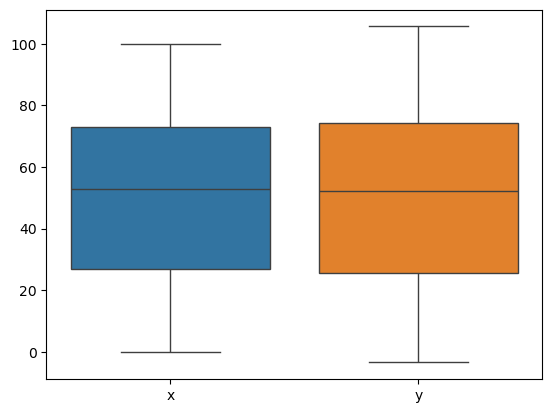

In [6]:
#handle outliers
sns.boxplot(data)

In [7]:
#handle outliers using IQR
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
data = data[~((data < (Q1 - 1.5 * IQR)) |(data > (Q3 + 1.5 * IQR))).any(axis=1)]    


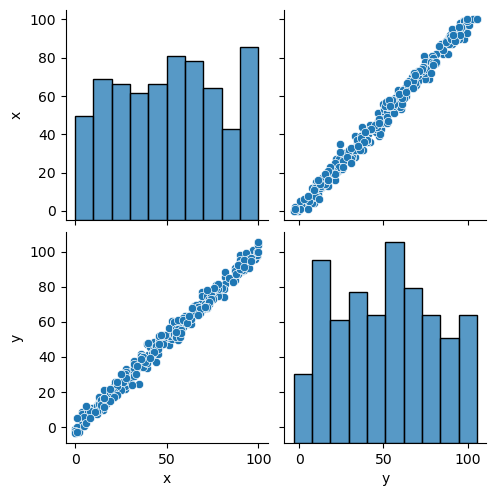

In [8]:
#visualize the data
sns.pairplot(data)
plt.show()

<Axes: >

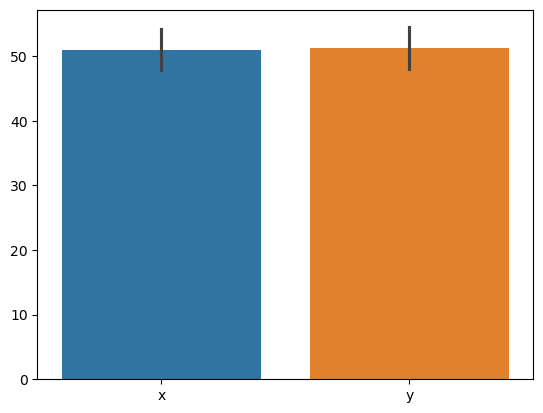

In [9]:
sns.barplot(data)

In [11]:
#div the dataset into features and target variable
X = data.drop('x', axis=1)
y = data['x']

In [18]:

#create svr
from sklearn.svm import SVR
svr = SVR(kernel='rbf')
svr.fit(X, y)
#train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)   
#train the model
model = LinearRegression()
model.fit(X_train, y_train)
#make predictions
y_pred = model.predict(X_test)
#evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print('Mean Squared Error:', mse)
print('R2 Score:', r2)

Mean Squared Error: 8.859598347782258
R2 Score: 0.9909046787157905


In [15]:
from sklearn.datasets import make_regression
#create dataset
x1,y1=make_regression(n_samples=100, n_features=1, noise=10, random_state=42)
#split the dataset
X_train, X_test, y_train, y_test = train_test_split(x1, y1, test_size=0.2, random_state=42)
#create svr model
from sklearn.svm import SVR
model = SVR(kernel='rbf', C=1.0, gamma=0.1,epsilon=0.1)
#train the model
model.fit(X_train, y_train)
#make predictions
y_pred = model.predict(X_test)
#evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print('Mean Squared Error:', mse)
print('R2 Score:', r2)

Mean Squared Error: 1232.1806881403577
R2 Score: 0.2599406668585741
